<a href="https://colab.research.google.com/github/Amberbops/Notebooks-MP/blob/main/Copy_of_garbage_initiative.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
zlatan599_garbage_dataset_classification_path = kagglehub.dataset_download('zlatan599/garbage-dataset-classification')

print('Data source import complete.')


Data source import complete.


In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

Streaming output truncated to the last 5000 lines.
/kaggle/input/garbage-dataset-classification/Garbage_Dataset_Classification/images/trash/trash_05780.jpg
/kaggle/input/garbage-dataset-classification/Garbage_Dataset_Classification/images/trash/trash_03070.jpg
/kaggle/input/garbage-dataset-classification/Garbage_Dataset_Classification/images/trash/trash_13268.jpg
/kaggle/input/garbage-dataset-classification/Garbage_Dataset_Classification/images/trash/trash_08441.jpg
/kaggle/input/garbage-dataset-classification/Garbage_Dataset_Classification/images/trash/trash_11875.jpg
/kaggle/input/garbage-dataset-classification/Garbage_Dataset_Classification/images/trash/trash_05756.jpg
/kaggle/input/garbage-dataset-classification/Garbage_Dataset_Classification/images/trash/trash_18928.jpg
/kaggle/input/garbage-dataset-classification/Garbage_Dataset_Classification/images/trash/trash_18023.jpg
/kaggle/input/garbage-dataset-classification/Garbage_Dataset_Classification/images/trash/trash_05522.jpg
/kag

## Import Libs

In [ ]:
import tensorflow as tf
import keras
import os
import seaborn as sns
from keras.models import Sequential
from sklearn.metrics import classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')
from keras import models, layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline

##Settings

In [ ]:
IMG_HEIGHT = 224
IMG_WIDTH = 224
BATCH_SIZE = 32
EPOCHS = 5
NUM_CLASSES = 6

##Data Paths

In [ ]:
dir='/kaggle/input/garbage-dataset-classification/Garbage_Dataset_Classification/images'
classes=['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']

##Check Data Availability

In [ ]:
for class_name in classes:
   class_path = os.path.join(dir, class_name)
   if os.path.exists(class_path):
       num_images = len(os.listdir(class_path))
       print(f"{class_name}:{num_images} images")
   else:
       print(f"Error: folder {class_name} not found!")

cardboard:2214 images
glass:2500 images
metal:2084 images
paper:2315 images
plastic:2288 images
trash:2500 images


##Load and Analyze Data

In [ ]:
if os.path.exists("Garbage_Dataset_Classification/metadata.csv"):
  metadata = pd.read_csv("Garbage_Dataset_Classification/metadata.csv")
  print(metadata.head())
else:
  print("Error: metadata.csv not found")

Error: metadata.csv not found


## Create Data Generators

In [ ]:
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.2,
    horizontal_flip=True,
    zoom_range=0.2,
)

# Training Generator
train_datagen = datagen.flow_from_directory(
    dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True,
)

# Validation Generator
val_datagen = datagen.flow_from_directory(
    dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=True,
)
print(f"\nClasses: {train_datagen.class_indices}")

Found 11123 images belonging to 6 classes.
Found 2778 images belonging to 6 classes.

Classes: {'cardboard': 0, 'glass': 1, 'metal': 2, 'paper': 3, 'plastic': 4, 'trash': 5}


##Create Model

In [ ]:
def create_model():
  base_model = keras.applications.MobileNetV2(
      input_shape=(IMG_HEIGHT, IMG_WIDTH, 3),
      include_top=False,
      weights='imagenet',
  )
  base_model.trainable = True
  model=Sequential([
      base_model,
      layers.GlobalAveragePooling2D(),
      layers.Dropout(0.3),
      layers.Dense(128, activation='relu'),
      layers.Dropout(0.3), # Corrected typo here
      layers.Dense(NUM_CLASSES, activation='softmax'),
  ])
  return model

model=create_model()

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

#Callbacks

early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    #min_lr=1e-7, # Removed min_lr as it is not a valid argument
)

reduce_lr = keras.callbacks.ReduceLROnPlateau( # Corrected typo
    factor=0.2,
    patience=3,
    min_lr=1e-7,
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


## Train Model

In [ ]:
history = model.fit(
    train_datagen,
    epochs=EPOCHS,
    validation_data=val_datagen,
    callbacks=[early_stopping, reduce_lr],
    verbose=1,
)

#save model
model.save('garbage_classification_model.h5')
print(f'Model saved as garbage_classification_model.h5')

Epoch 1/5
348/348 ━━━━━━━━━━━━━━━━━━━━ 340s 771ms/step - accuracy: 0.6449 - loss: 1.0032 - val_accuracy: 0.3312 - val_loss: 4.2950 - learning_rate: 0.0010
Epoch 2/5
348/348 ━━━━━━━━━━━━━━━━━━━━ 177s 510ms/step - accuracy: 0.7870 - loss: 0.6402 - val_accuracy: 0.2567 - val_loss: 9.0119 - learning_rate: 0.0010
Epoch 3/5
348/348 ━━━━━━━━━━━━━━━━━━━━ 180s 518ms/step - accuracy: 0.8216 - loss: 0.5334 - val_accuracy: 0.3193 - val_loss: 10.6646 - learning_rate: 0.0010
Epoch 4/5
348/348 ━━━━━━━━━━━━━━━━━━━━ 179s 515ms/step - accuracy: 0.8462 - loss: 0.4604 - val_accuracy: 0.4442 - val_loss: 5.0801 - learning_rate: 0.0010


Model saved as garbage_classification_model.h5


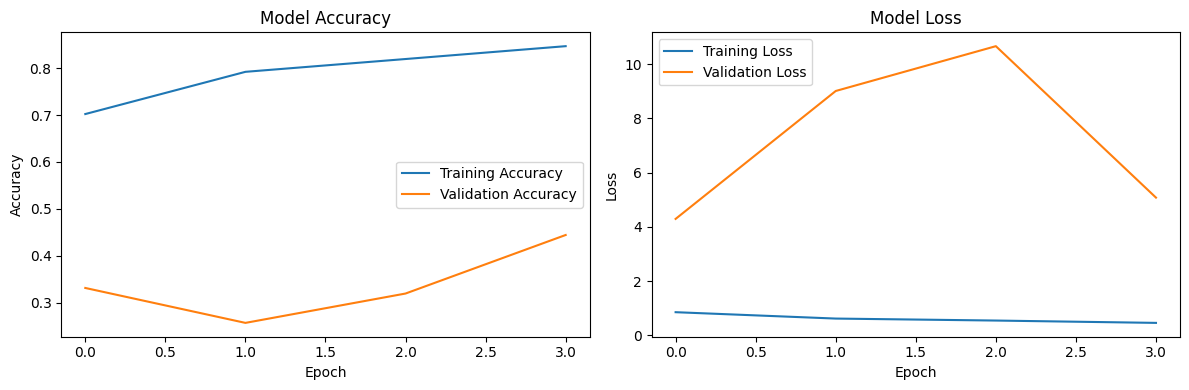


Evaluating model on validation data:
87/87 ━━━━━━━━━━━━━━━━━━━━ 36s 415ms/step - accuracy: 0.4389 - loss: 5.0191
Validation Accuracy: 0.4460
Validation Loss: 5.0578
87/87 ━━━━━━━━━━━━━━━━━━━━ 45s 460ms/step


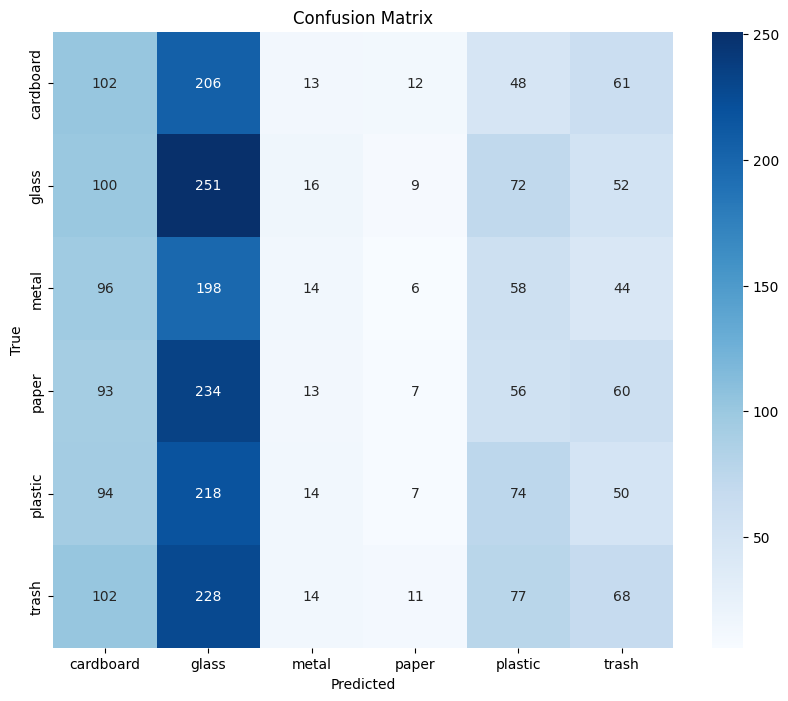


Additional information:
Total images: 13901
Batch size: 32
Image size: 224x224

RUNNING PREDICTIONS ON 10 IMAGES

PREDICTING 10 RANDOM IMAGES FROM TEST SET
Image 1: plastic_02504.jpg
  Predicted: plastic
  Confidence: 0.8612
--------------------------------------------------
Image 2: paper_02532.jpg
  Predicted: cardboard
  Confidence: 0.9994
--------------------------------------------------
Image 3: glass_01067.jpg
  Predicted: glass
  Confidence: 0.9999
--------------------------------------------------
Image 4: metal_01381.jpg
  Predicted: cardboard
  Confidence: 0.8767
--------------------------------------------------
Image 5: cardboard_02195.jpg
  Predicted: cardboard
  Confidence: 0.9995
--------------------------------------------------
Image 6: trash_15838.jpg
  Predicted: trash
  Confidence: 1.0000
--------------------------------------------------
Image 7: plastic_01891.jpg
  Predicted: plastic
  Confidence: 1.0000
--------------------------------------------------
Image 8

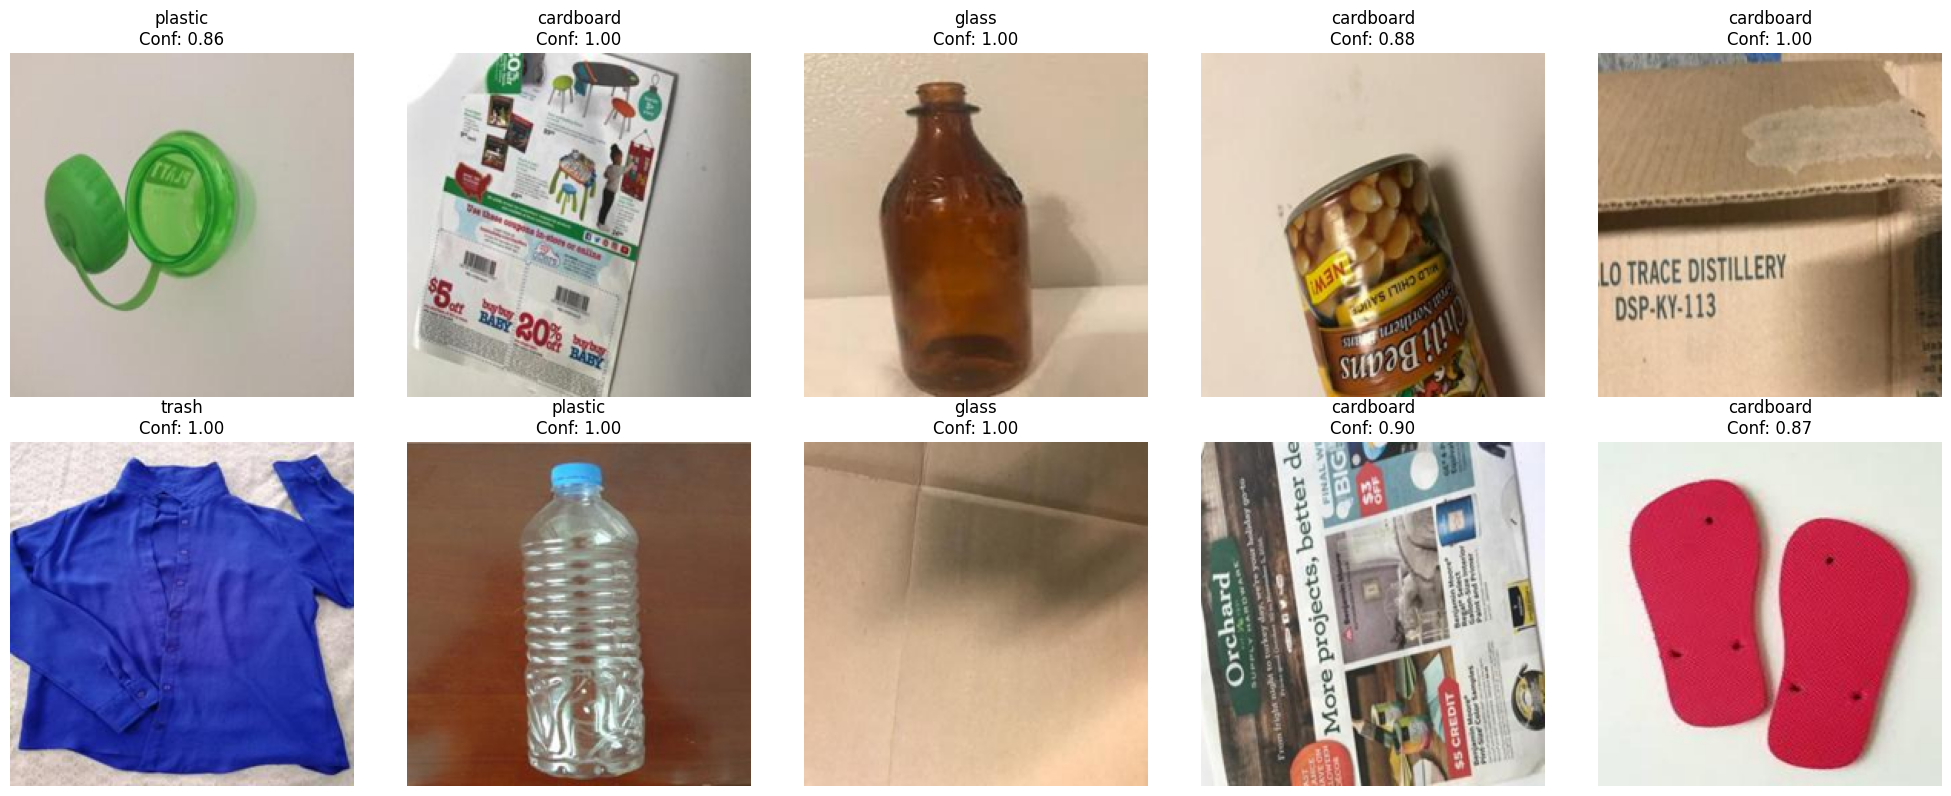


Prediction completed!
Results saved in 'multiple_predictions.png'


In [ ]:
# Visualize training results
def plot_training_history(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    # Accuracy plot
    ax1.plot(history.history['accuracy'], label='Training Accuracy')
    ax1.plot(history.history['val_accuracy'], label='Validation Accuracy')
    ax1.set_title('Model Accuracy')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy')
    ax1.legend()

    # Loss plot
    ax2.plot(history.history['loss'], label='Training Loss')
    ax2.plot(history.history['val_loss'], label='Validation Loss')
    ax2.set_title('Model Loss')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend()

    plt.tight_layout()
    plt.savefig('training_history.png')
    plt.show()

plot_training_history(history)

# Model evaluation
print("\nEvaluating model on validation data:")
val_loss, val_accuracy = model.evaluate(val_datagen) # Corrected validation_generator to val_datagen
print(f"Validation Accuracy: {val_accuracy:.4f}")
print(f"Validation Loss: {val_loss:.4f}")

# Predictions and confusion matrix
val_datagen.reset() # Corrected validation_generator to val_datagen
y_pred = model.predict(val_datagen) # Corrected validation_generator to val_datagen
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = val_datagen.classes # Corrected validation_generator to val_datagen

# Confusion matrix
cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.savefig('confusion_matrix.png')
plt.show()

# Import Image from PIL
from PIL import Image

# Function for predicting new images
def predict_image(image_path, model, class_names):
    img = Image.open(image_path)
    img = img.resize((IMG_HEIGHT, IMG_WIDTH))
    img_array = np.array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    prediction = model.predict(img_array)
    predicted_class = np.argmax(prediction)
    confidence = np.max(prediction)

    plt.figure(figsize=(8, 6))
    plt.imshow(img)
    plt.title(f'Predicted: {class_names[predicted_class]}\nConfidence: {confidence:.2f}')
    plt.axis('off')
    plt.show()

    return class_names[predicted_class], confidence

# Function to predict multiple images
def predict_multiple_images(image_paths, model, class_names):
    """
    Predict classes for multiple images

    Args:
        image_paths: list of paths to images
        model: trained model
        class_names: list of class names
    """
    results = []

    fig, axes = plt.subplots(2, 5, figsize=(20, 8))
    axes = axes.ravel()

    for i, image_path in enumerate(image_paths):
        if i >= 10:  # Limit to 10 images
            break

        try:
            img = Image.open(image_path)
            img = img.resize((IMG_HEIGHT, IMG_WIDTH))
            img_array = np.array(img) / 255.0
            img_array = np.expand_dims(img_array, axis=0)

            prediction = model.predict(img_array, verbose=0)
            predicted_class_idx = np.argmax(prediction)
            confidence = np.max(prediction)
            predicted_class = class_names[predicted_class_idx]

            # Display image with prediction
            axes[i].imshow(img)
            axes[i].set_title(f'{predicted_class}\nConf: {confidence:.2f}')
            axes[i].axis('off')

            results.append({
                'image_path': image_path,
                'predicted_class': predicted_class,
                'confidence': confidence,
                'all_predictions': prediction[0]
            })

            print(f"Image {i+1}: {os.path.basename(image_path)}")
            print(f"  Predicted: {predicted_class}")
            print(f"  Confidence: {confidence:.4f}")
            print("-" * 50)

        except Exception as e:
            print(f"Error processing {image_path}: {e}")
            results.append({
                'image_path': image_path,
                'error': str(e)
            })

    plt.tight_layout()
    plt.savefig('multiple_predictions.png')
    plt.show()

    return results

# Example usage for multiple images
def predict_10_random_test_images():
    """
    Predict 10 random images from the test dataset
    """
    print("\n" + "="*60)
    print("PREDICTING 10 RANDOM IMAGES FROM TEST SET")
    print("="*60)

    # Define data_dir
    data_dir = '/kaggle/input/garbage-dataset-classification/Garbage_Dataset_Classification/images'

    # Collect 10 random images from each class
    test_images = []
    for class_name in classes:
        class_path = os.path.join(data_dir, class_name)
        if os.path.exists(class_path):
            images = [os.path.join(class_path, img) for img in os.listdir(class_path)[:2]]  # 2 from each class
            test_images.extend(images)

    # Shuffle and take 10
    np.random.shuffle(test_images)
    selected_images = test_images[:10]

    # Predict
    results = predict_multiple_images(selected_images, model, classes)

    return results

# Function to predict images from a specific folder
def predict_images_from_folder(folder_path, model, class_names, num_images=10):
    """
    Predict images from a specific folder

    Args:
        folder_path: path to folder containing images
        model: trained model
        class_names: list of class names
        num_images: number of images to predict
    """
    if not os.path.exists(folder_path):
        print(f"Folder {folder_path} does not exist!")
        return []

    image_extensions = ['.jpg', '.jpeg', '.png', '.bmp', '.tiff']
    image_paths = []

    for file in os.listdir(folder_path):
        if any(file.lower().endswith(ext) for ext in image_extensions):
            image_paths.append(os.path.join(folder_path, file))

    if not image_paths:
        print("No images found in the folder!")
        return []

    # Take up to num_images
    selected_images = image_paths[:min(num_images, len(image_paths))]

    print(f"\nPredicting {len(selected_images)} images from {folder_path}:")
    results = predict_multiple_images(selected_images, model, class_names)

    return results

# Additional data information
print("\nAdditional information:")
# Define data_dir for this section as well
data_dir = '/kaggle/input/garbage-dataset-classification/Garbage_Dataset_Classification/images'
total_images = sum([len(os.listdir(os.path.join(data_dir, cls))) for cls in classes])
print(f"Total images: {total_images}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Image size: {IMG_HEIGHT}x{IMG_WIDTH}")

# ===== PREDICTION SECTION =====
print("\n" + "="*60)
print("RUNNING PREDICTIONS ON 10 IMAGES")
print("="*60)

# Option 1: Predict 10 random images from test set
test_results = predict_10_random_test_images()

# Option 2: Uncomment below to predict images from a specific folder
# folder_to_predict = "path/to/your/test/images"
# folder_results = predict_images_from_folder(folder_to_predict, model, classes, 10)

# Option 3: Uncomment below to predict specific image paths
# specific_images = [
#     "path/to/image1.jpg",
#     "path/to/image2.jpg",
#     # ... add up to 10 images
# ]
# specific_results = predict_multiple_images(specific_images, model, classes)

print("\nPrediction completed!")
print("Results saved in 'multiple_predictions.png'")